In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [131]:
file_path = "data/sales_dataset.xlsx"

df = pd.read_excel("Sample data (1) (1).xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 700
Columns: 16


In [132]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [134]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


In [135]:
df.columns = df.columns.str.strip()

print("Column names cleaned successfully.")
print(df.columns.tolist())

Column names cleaned successfully.
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [136]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 700
Columns: 16


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [139]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_summary

,Missing Values,Percentage
Segment,0,0.000000
Country,0,0.000000
Product,0,0.000000
Discount Band,53,7.571429
Units Sold,0,0.000000
Manufacturing Price,0,0.000000
Sale Price,0,0.000000
Gross Sales,0,0.000000
Discounts,0,0.000000
Sales,0,0.000000


In [140]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [141]:
df["Discount Band"] = df["Discount Band"].fillna("Unknown")

print("Missing Discount Band values:",
      df["Discount Band"].isnull().sum())

Missing Discount Band values: 0


In [142]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully.")
print(df["Date"].dtype)

Date column converted successfully.
datetime64[ns]


In [143]:
print("Sales column exists:", "Sales" in df.columns)

print("\nFirst 5 Sales values:")
print(df["Sales"].head())

Sales column exists: True

First 5 Sales values:
0    529550.0
1    352100.0
2    603750.0
3    529550.0
4    352100.0
Name: Sales, dtype: float64


In [144]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_units = df["Units Sold"].sum()
average_sales = df["Sales"].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Units Sold:", round(total_units, 2))
print("Average Sales:", round(average_sales, 2))

Total Sales: 118726350.26
Total Profit: 16893702.26
Total Units Sold: 1125806.0
Average Sales: 169609.07


In [145]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

yearly_sales

,Year,Sales
0,2013,26415255.51
1,2014,92311094.75


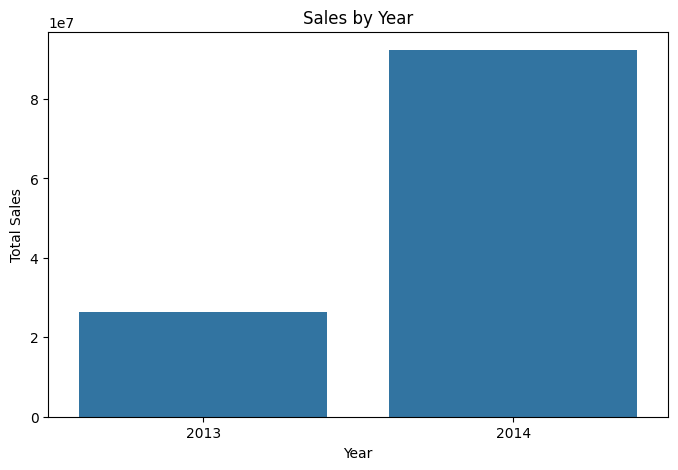

In [146]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales"
)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [147]:
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_sales

,Product,Sales
0,Paseo,3.301114e+07
1,VTT,2.051192e+07
2,Velo,1.825006e+07
3,Amarilla,1.774712e+07
4,Montana,1.539080e+07
5,Carretera,1.381531e+07


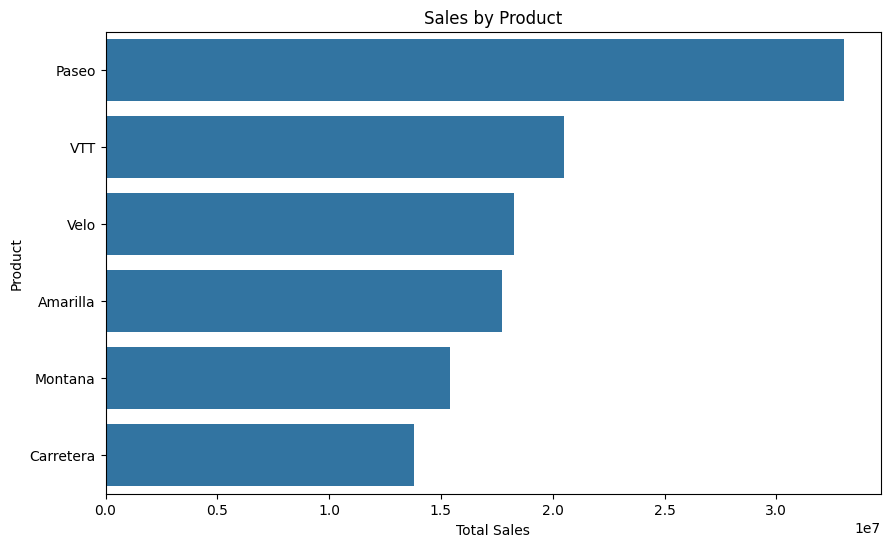

In [148]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_sales,
    x="Sales",
    y="Product"
)

plt.title("Sales by Product")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

In [149]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_sales

,Segment,Sales
0,Government,5.250426e+07
1,Small Business,4.242792e+07
2,Enterprise,1.961169e+07
3,Midmarket,2.381883e+06
4,Channel Partners,1.800594e+06


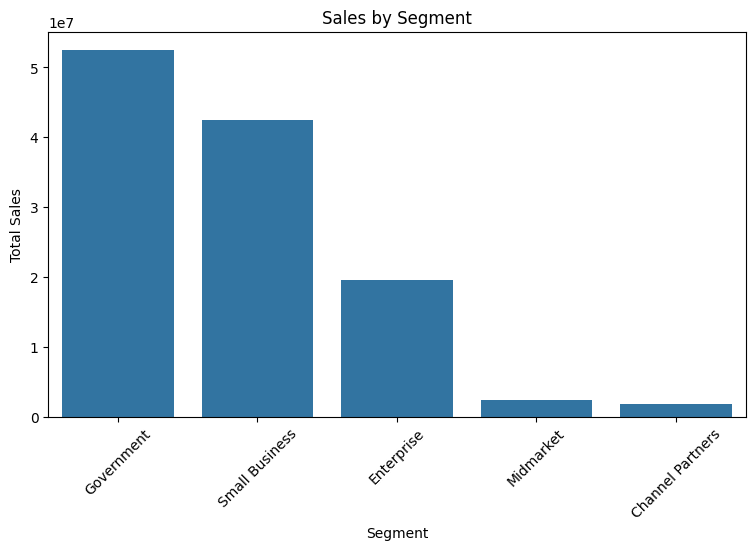

In [150]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_sales,
    x="Segment",
    y="Sales"
)

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [151]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_sales.head(10)

,Country,Sales
0,United States of America,2.502983e+07
1,Canada,2.488765e+07
2,France,2.435417e+07
3,Germany,2.350534e+07
4,Mexico,2.094935e+07


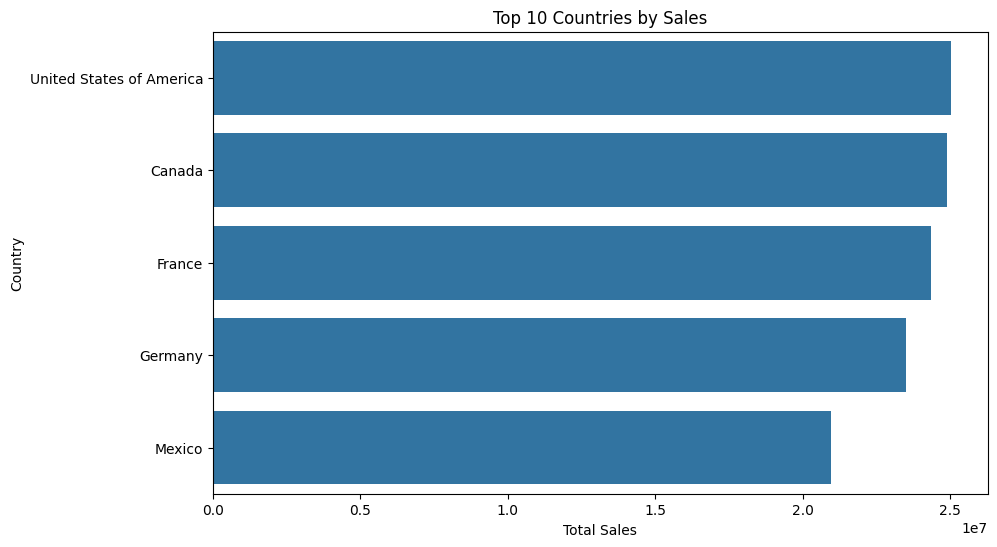

In [152]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_sales.head(10),
    x="Sales",
    y="Country"
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.show()

In [153]:
product_profit = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_profit

,Product,Profit
0,Paseo,4797437.950
1,VTT,3034608.020
2,Amarilla,2814104.060
3,Velo,2305992.465
4,Montana,2114754.880
5,Carretera,1826804.885


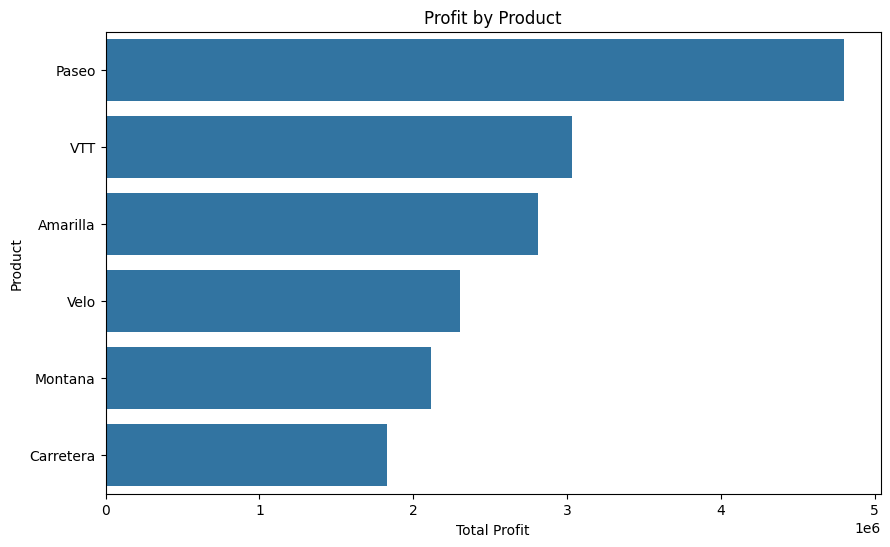

In [154]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_profit,
    x="Profit",
    y="Product"
)

plt.title("Profit by Product")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.show()

In [155]:
monthly_sales = (
    df.groupby("Month Number")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month Number")
)

monthly_sales

,Month Number,Sales
0,1,6607761.68
1,2,7297531.39
2,3,5586859.87
3,4,6964775.07
4,5,6210211.06
5,6,9518893.82
6,7,8102920.18
7,8,5864622.42
8,9,10882697.27
9,10,21671431.02


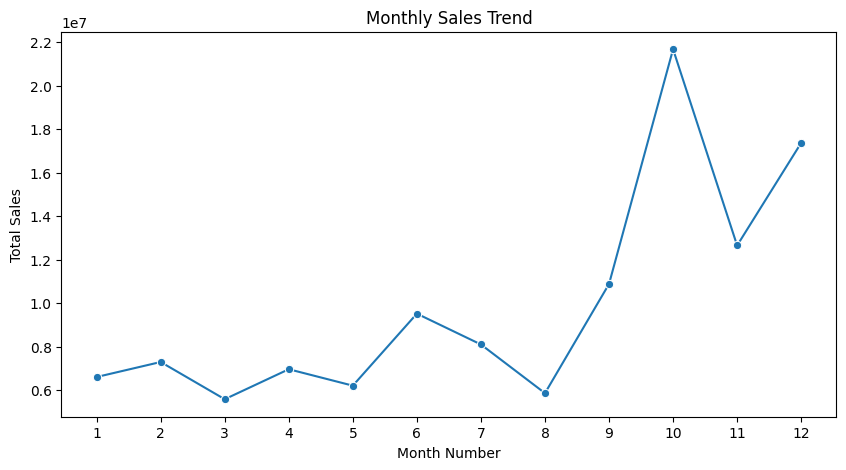

In [156]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month Number",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.show()

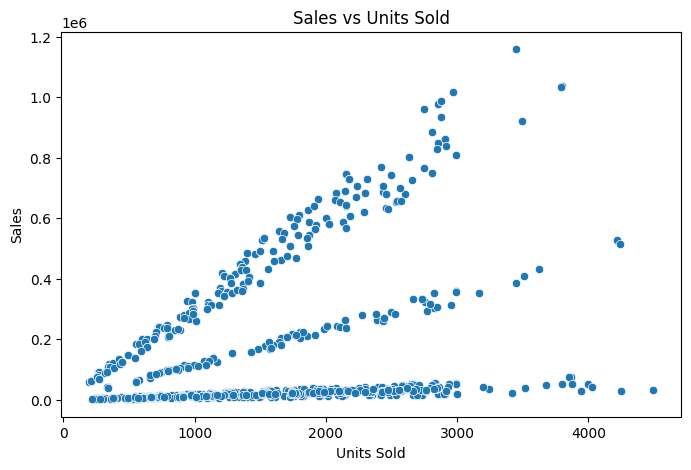

In [157]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Units Sold",
    y="Sales"
)

plt.title("Sales vs Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Sales")

plt.show()

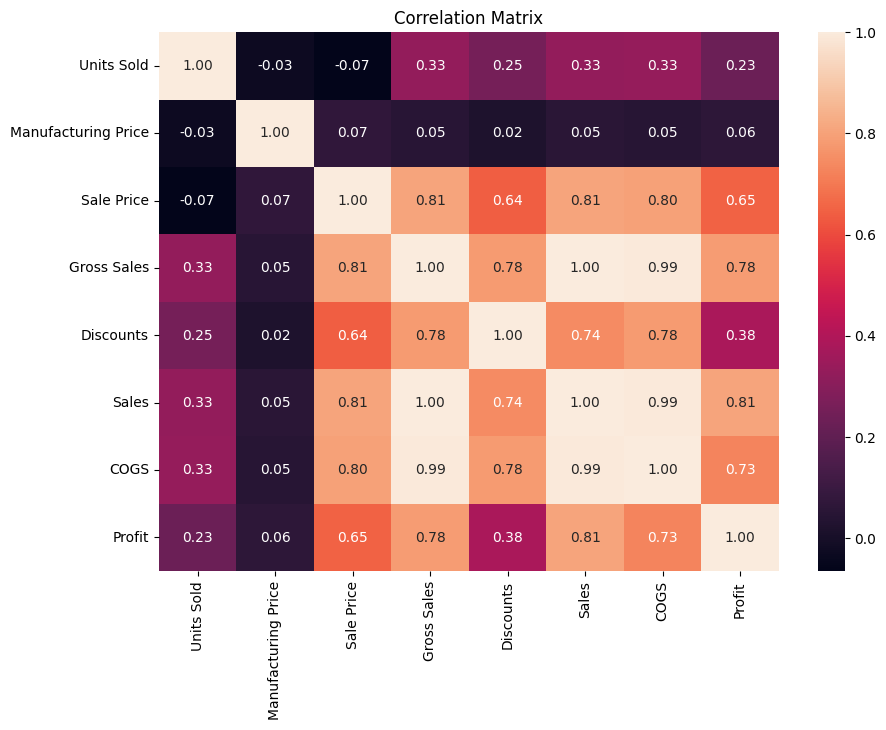

In [158]:
numeric_columns = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Gross Sales",
    "Discounts",
    "Sales",
    "COGS",
    "Profit"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [159]:
print("Top 10 Products by Sales:")
print(product_sales.head(10))

print("\nTop 10 Countries by Sales:")
print(country_sales.head(10))

Top 10 Products by Sales:
     Product         Sales
0      Paseo  3.301114e+07
1        VTT  2.051192e+07
2       Velo  1.825006e+07
3   Amarilla  1.774712e+07
4    Montana  1.539080e+07
5  Carretera  1.381531e+07

Top 10 Countries by Sales:
                    Country         Sales
0  United States of America  2.502983e+07
1                    Canada  2.488765e+07
2                    France  2.435417e+07
3                   Germany  2.350534e+07
4                    Mexico  2.094935e+07


## EDA Summary

The exploratory data analysis was performed to understand the sales dataset and identify important business patterns.

The analysis examined:

- Total sales and profit
- Sales by year
- Sales by product
- Sales by segment
- Sales by country
- Profit by product
- Monthly sales trends
- Relationship between units sold and sales
- Correlation between numerical variables

These findings will be used to understand the major factors affecting sales and to build a regression model for sales prediction.

Regression model

In [160]:
features = [
    "Segment",
    "Country",
    "Product",
    "Discount Band",
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Month Number",
    "Year"
]

X = df[features]
y = df["Sales"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: Sales")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Month Number', 'Year']

Target: Sales

X shape: (700, 9)
y shape: (700,)


In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 560
Testing records: 140


In [162]:
categorical_features = [
    "Segment",
    "Country",
    "Product",
    "Discount Band"
]

numerical_features = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Month Number",
    "Year"
]

In [163]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [164]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [165]:
regression_pipeline.fit(X_train, y_train)

print("Regression model trained successfully.")

Regression model trained successfully.


In [166]:
y_pred = regression_pipeline.predict(X_test)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[ 11844.4632   233904.83875   41570.790125  27470.239125  21843.941625
  22939.4494    15031.76045   18206.3098    31439.85225  327208.75    ]


In [167]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
-----------------
MAE : 11220.58
RMSE: 30318.24
R²  : 0.9834


In [168]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,12066.600,11844.463200
1,230310.000,233904.838750
2,40769.250,41570.790125
3,27968.000,27470.239125
4,23436.000,21843.941625
5,31133.025,22939.449400
6,15474.550,15031.760450
7,18035.920,18206.309800
8,32670.000,31439.852250
9,334302.500,327208.750000


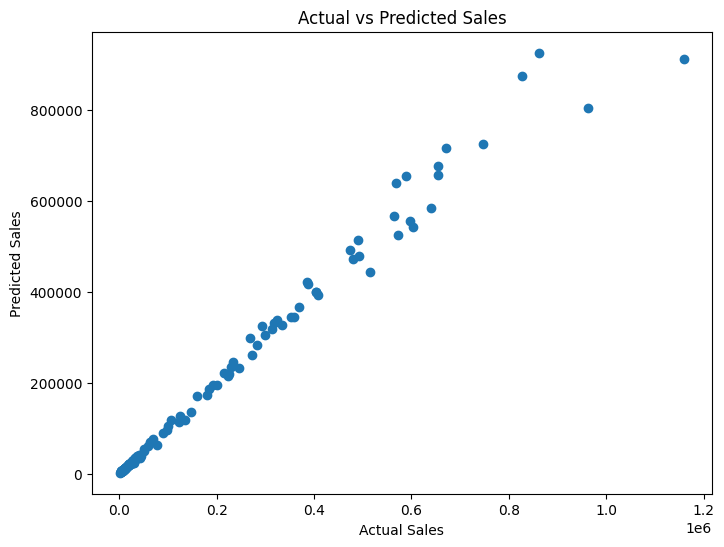

In [169]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["Actual Sales"],
    comparison["Predicted Sales"]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Regression Model Conclusion

A Random Forest Regression model was developed to predict Sales using product, country, segment, discount band, units sold, pricing, month, and year information.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The evaluation results are used to understand how well the model predicts sales on unseen test data.

In [171]:
import os

# Create output folder if it does not exist
os.makedirs("output", exist_ok=True)

# Save cleaned dataset
output_file = "output/cleaned_sales_data.xlsx"

df.to_excel(output_file, index=False)

print("Cleaned Excel file saved successfully!")
print(output_file)

Cleaned Excel file saved successfully!
output/cleaned_sales_data.xlsx


In [174]:
with pd.ExcelWriter(
    "output/sales_analysis_summary.xlsx",
    engine="openpyxl"
) as writer:

    yearly_sales.to_excel(
        writer,
        sheet_name="Yearly Sales",
        index=False
    )

    product_sales.to_excel(
        writer,
        sheet_name="Product Sales",
        index=False
    )

    segment_sales.to_excel(
        writer,
        sheet_name="Segment Sales",
        index=False
    )

    country_sales.to_excel(
        writer,
        sheet_name="Country Sales",
        index=False
    )

    product_profit.to_excel(
        writer,
        sheet_name="Product Profit",
        index=False
    )

    comparison.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

print("Analysis summary Excel file created successfully!")

Analysis summary Excel file created successfully!
